# 4장 복습과제 — 4-1 분류의 개요 & 4-2 결정 트리

## **문제 1. (개념) 지도학습과 분류**

- 지도학습(Supervised Learning)이 무엇인지 한 문장으로 설명하세요.
- 분류(Classification)를 구현할 수 있는 알고리즘을 3가지 이상 적어보세요.

**답변**

- 지도학습: 정답(label)이 있는 데이터를 이용해 컴퓨터가 입력과 정답 사이의 관계를 학습하도록 하는 머신러닝 방법
- 분류 알고리즘 3가지: 나이브 베이즈, 로지스틱 회귀, 결정 트리 

## **문제 2. (개념) 정보 이득 vs 지니 계수**

결정 트리가 노드를 분할할 때 사용하는 두 가지 균일도 측정 방법인 **정보 이득(Information Gain)**과 **지니 계수(Gini Index)**를 각각 한 문장으로 설명하고, 사이킷런의 `DecisionTreeClassifier`가 기본으로 사용하는 것은 무엇인지 적으세요.

**답변**

- 정보 이득: 1-엔트로피. 정보이득이 높을수록 데이터 균일도가 높다. 
- 지니 계수: 0이 가장 평등하고 1로 갈수록 불평등한 지수. 지니계수가 낮을수록 데이터 균일도가 높다. 결정트리에서는 지니계수가 낮은 속성을 기준으로 분할한다. 
- 사이킷런 기본값: 지니 계수

## **문제 3. Breast Cancer 데이터 로딩 및 train/test 분리**

- sklearn 패키지의 `load_breast_cancer` 데이터셋을 이용합니다.
- 유방암 세포의 특징(반지름, 텍스처 등)을 기반으로 악성(malignant)/양성(benign)을 분류하는 이진 분류 데이터셋입니다.
- `train_test_split`을 통해 학습용 75%, 테스트용 25%로 분리하세요. (`random_state=42`)

In [3]:
## 데이터 준비
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 데이터 로드
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# 데이터 훈련/테스트 세트로 분할 (75:25 비율, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## **문제 4. DecisionTreeClassifier로 모델 학습 및 정확도 평가**

- `criterion='gini'`, `max_depth=4`, `random_state=42`로 결정 트리 모델을 생성하고 학습시키세요.
- 테스트 데이터에 대한 예측을 수행하고 정확도(accuracy)를 출력하세요.

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 생성 및 학습
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train, y_train)

# 테스트 세트에 대한 예측 및 정확도 계산
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('결정 트리 예측 정확도 : {0:.4f}'.format(accuracy))

결정 트리 예측 정확도 : 0.9510


♦️ 노드 정보 설명

- feature <= threshold : 데이터를 나누는 기준
- gini : 노드의 불순도 (0에 가까울수록 순수)
- samples : 해당 노드에 포함된 데이터 수
- value : 각 클래스별 데이터 개수
    예: [40, 5] → 첫 번째 클래스가 대부분

## **문제 5. GridSearchCV를 이용한 하이퍼파라미터 튜닝**

- `max_depth`: [3, 5, 7, 9], `min_samples_split`: [2, 4, 6] 조합으로 그리드서치를 수행하세요.
- `cv=5`로 교차검증하고, 최적 파라미터와 최고 평균 정확도를 출력하세요.
- 최적 모델(`best_estimator_`)로 테스트 데이터 정확도를 다시 평가하세요.

In [7]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 4, 6]
}

dt = DecisionTreeClassifier(max_depth=4, random_state=42)

grid_cv = GridSearchCV(dt, param_grid=params, scoring='accuracy', cv=5)
grid_cv.fit(X_train, y_train)

print("최적 하이퍼 파라미터:", grid_cv.best_params_)
print("최고 평균 정확도:", grid_cv.best_score_)

# 최적 모델로 테스트 세트 재평가
best_dt_clf = grid_cv.best_estimator_
pred = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('최종 테스트 정확도 : {0:.4f}'.format(accuracy))

최적 하이퍼 파라미터: {'max_depth': 7, 'min_samples_split': 2}
최고 평균 정확도: 0.9365800273597811
최종 테스트 정확도 : 0.9510


## **문제 6. Feature Importance 시각화**

- 문제 5에서 얻은 최적 모델(`best_dt_clf`)에서 `feature_importances_` 속성을 추출하세요.
- 중요도 상위 10개 피처를 막대그래프(`sns.barplot`)로 시각화하세요.

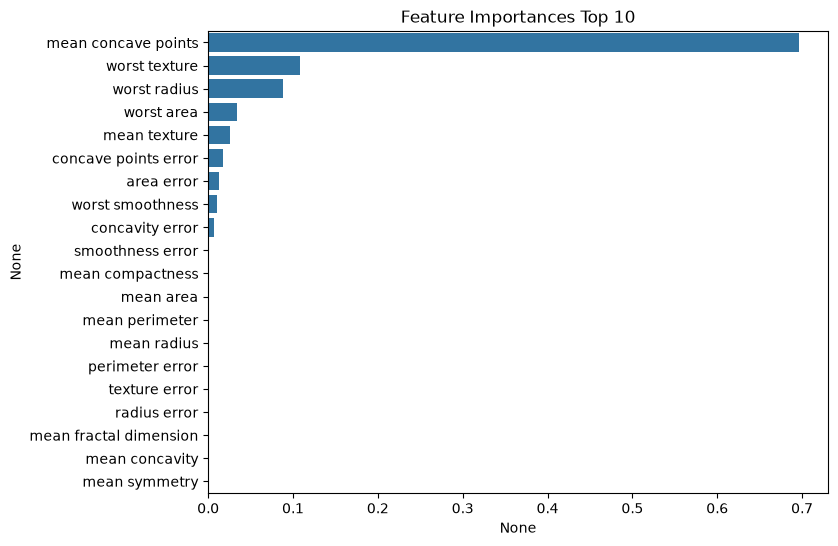

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 최적 모델에서 피처 중요도 추출
ftr_importances_values = best_dt_clf.feature_importances_

# Series로 변환
ftr_importances = pd.Series(
    ftr_importances_values,
    index=cancer.feature_names
    )

# 중요도 상위 10개만 추출
ftr_top10 = ftr_importances.sort_values(ascending=False)[:20]

# 시각화
plt.figure(figsize=(8,6))
plt.title('Feature Importances Top 10')

sns.barplot(
    x=ftr_top10,
    y=ftr_top10.index
    )

plt.show()

# **4-3 앙상블 학습**

# 1) 데이터셋 불러오기 및 분리
### load_breast_cancer()를 이용하여 유방암 데이터셋을 불러온 후 훈련 세트와 테스트 세트로 분리해 주세요.

* test_size = 0.25
* random_state = 113



In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer=load_breast_cancer()
X_train, X_test, y_train, y_test= train_test_split(cancer.data, cancer.target, test_size=0.25, random_state=113)

# 2) 개별 분류기 학습 및 평가
### 다음 세 개의 분류기를 생성하고 각각 학습/예측한 후 정확도를 출력해 주세요.

*  Logistic Regression: solver = 'liblinear'
*  KNN: n_neighbors = 6
*  Decision Tree: max_depth=4

> #### 반복되는 학습/예측/평가 과정은 반복문을 이용하세요.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#모델 생성
lr_clf= LogisticRegression(solver='liblinear')
knn_clf= KNeighborsClassifier(n_neighbors=6)
dt_clf= DecisionTreeClassifier(max_depth=4)

classifiers= [lr_clf, knn_clf, dt_clf] 
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred= classifier.predict(X_test)
    accuracy= accuracy_score(y_test, pred)
    print('{0}의 정확도:{1:.4f}'.format(classifier, accuracy))



LogisticRegression(solver='liblinear')의 정확도:0.9371
KNeighborsClassifier(n_neighbors=6)의 정확도:0.9301
DecisionTreeClassifier(max_depth=4)의 정확도:0.9021


# 3) Hard Voting과 Soft Voting
### 3-1) 2번에서 생성한 세 개의 분류기를 이용하여 Hard Voting 방식의 VotingClassifier를 생성하세요.



In [20]:
from sklearn.ensemble import VotingClassifier

hard_clf= VotingClassifier(estimators=[('LR', lr_clf), ('KNN', knn_clf), ('DT', dt_clf)],
                            voting='hard')

### 3-2) 모델을 학습한 후 테스트 데이터의 정확도(소숫점 넷째자리까지)를 출력하세요.

In [22]:
hard_clf.fit(X_train, y_train)
pred=hard_clf.predict(X_test)
accuracy=accuracy_score(y_test, pred)
print('정확도:{0:.4f}'.format(accuracy))

정확도:0.9441


### 3-3) Hard Voting과 Soft Voting의 차이를 설명하세요.

*(답안 작성)*
하드보팅은 예측한 결괏값들 중 다수의 분류기가 결정한 예측값을 최종 결괏값으로 선정하는 반면, 소프트 보팅은 분류기들의 레이블 값 결정 확률을 평균하여 이들 중 확률이 가장 높은 레이블 값을 최종 결괏값으로 선정한다. 

# 4) Bagging과 Pasting

### 4-1)  300개의 결정 트리가 중복을 허용하여 80개의 훈련 샘플을 추출하도록 모델을 생성하세요.
> n_jobs = -1로 설정



In [34]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bg_clf = BaggingClassifier(n_estimators=300, max_samples=80, bootstrap=True, n_jobs=-1)

### 4-2)  300개의 결정 트리가 중복을 허용하지 않고 80개의 훈련 샘플을 추출하도록 모델을 생성하세요.
> n_jobs = -1로 설정

In [35]:
bg_clf2= BaggingClassifier(n_estimators=300, max_samples=80, bootstrap=False, n_jobs=-1)

### 4-3) 두 모델을 각각 학습하고, 예측 성능을 소숫점 넷째자리까지 평가하세요. (이때, 각 모델의 학습방식을 함께 표시하여 출력하세요.)
        출력 방식: Bagging/Pasting 정확도: 0.xxxx



In [37]:
bg_clf.fit(X_train, y_train)
pred1= bg_clf.predict(X_test)
accuracy1= accuracy_score(y_test, pred1)

bg_clf2.fit(X_train, y_train)
pred2= bg_clf2.predict(X_test)
accuracy2= accuracy_score(y_test, pred2)

print('Bagging 정확도: {0:.4f}'.format(accuracy1))
print('Pasting 정확도: {0:.4f}'.format(accuracy2))

Bagging 정확도: 1.0000
Pasting 정확도: 0.9556


# 5) oob 평가
### 5-1) 4번의 Bagging 모델과 동일한 조건으로 oob 평가가 가능한 모델을 생성하고 학습하세요.

In [38]:
bg_clf3 = BaggingClassifier(n_estimators=300, max_samples=80, bootstrap=True, n_jobs=-1, oob_score=True)
bg_clf3.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",300
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",80
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


### 5-2) 학습된 모델의 oob 점수와 테스트 데이터셋에 대한 정확도를 각각 소수점 넷째 자리까지 출력하여 비교하세요.

In [39]:
print('oob Score: {0:.4f}'.format(bg_clf3.oob_score_))

pred3 = bg_clf3.predict(X_test)
print('Accuracy: {0:.4f}'.format(accuracy_score(y_test, pred3)))

oob Score: 0.9398
Accuracy: 0.9778


# 랜덤 포레스트
 - '##답변 작성## 부분에 코드를 작성해주세요.
 - '##답변 작성##' 이 아닌 부분(변수명, 미리 작성된 코드)은 수정하지 마세요.


1) 사이킷런의 load_digits 데이터셋을 RandomForestClassifier을 이용해 예측하시오.

In [24]:
# 필요한 라이브러리 임포트 - 실행해주세요!
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


# 데이터셋 설정
digits = load_digits()
digits_data = digits.data
digits_target = digits.target


# 데이터를 학습/테스트 데이터로 분리
# test_size = 0.25, random_state = 21
X_train, X_test, y_train, y_test= train_test_split(digits_data, digits_target, test_size = 0.25, random_state = 21)


# Random Forest 객체 생성 및 예측
digits_rf = RandomForestClassifier(random_state = 10, max_depth = 7)
digits_rf.fit(X_train, y_train)
pred = digits_rf.predict(X_test)


# estimate accuracy
acc = accuracy_score(y_test, pred)
print('Random Forest accuracy: {0:.4f}'.format(acc))


Random Forest accuracy: 0.9600


2) load_wine 데이터셋을 이용하여 GradientBoostingClassifier 모델을 학습하고, GridSearchCV를 활용하여 최적의 하이퍼파라미터를 찾으시오.

✅ 조건
데이터셋:
1. load_wine() 사용

2. 훈련 데이터 75% / 테스트 데이터 (25%)로 분리

3. random_state=21 사용. GridSearchCV를 이용하여 하이퍼파라미터 튜닝


4. learning_rate: [0.05, 0.1, 0.15], n_estimators: [100, 200, 300], max_depth: [2, 4, 6]

5. 최적의 하이퍼파라미터를 찾은 후 테스트 데이터로 예측

6. 테스트 데이터의 정확도를 출력할 것

✅ 참고사항
GridSearchCV는 여러 하이퍼파라미터 조합을 반복해서 학습하기 때문에 실행 시간이 다소 오래 걸릴 수 있습니다.

In [25]:
# 필요한 라이브러리 임포트
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


# 데이터셋 로드
wine = load_wine()
wine_data = wine.data
wine_target = wine.target


# 훈련 세트와 테스트 세트로 분리
# test_size=0.25, random_state=21
X_train, X_test, y_train, y_test =  train_test_split(wine_data, wine_target, test_size=0.25, random_state=21)

# learning_rate: [0.05, 0.1, 0.15], n_estimators: [100, 200, 300], max_depth: [2, 4, 6]
# 하이퍼파라미터 그리드 설정
params = {'learning_rate': [0.05, 0.1, 0.15], 'n_estimators': [100, 200, 300], 'max_depth': [2, 4, 6]
}


# GradientBoostingClassifier 객체 생성 후 GridSearchCV 수행
gb_clf = GradientBoostingClassifier(random_state=21)
grid_cv = GridSearchCV(
    gb_clf,
    param_grid=params,
    cv=4,
    n_jobs=-1
)


# 모델 학습
grid_cv.fit(X_train, y_train)


# 최적 하이퍼파라미터 출력
print('최적 하이퍼파라미터:\n', grid_cv.best_params_)


# 최적 모델로 테스트 데이터 예측
y_pred = grid_cv.predict(X_test)


# 정확도 출력
accuracy = accuracy_score(y_test, y_pred)
print('Gradient Boosting 예측 정확도: {0:.4f}'.format(accuracy))


최적 하이퍼파라미터:
 {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Gradient Boosting 예측 정확도: 0.9333


# 서포트 벡터 머신(SVM)
 3) 가우시안 RBF 커널을 사용하여 gamma 값이 2이고, 하이퍼파라미터 C의 값이 0.001인 SVM 분류기를 만드시오.

 - '##답변 작성## 부분에 코드를 작성해주세요.
 - '##답변 작성##' 이 아닌 부분(변수명, 미리 작성된 코드)은 수정하지 마세요.

In [26]:
# 필요한 라이브러리 임포트
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# moons 형태의 데이터 생성
X, y = make_moons(n_samples=200, noise=0.25)

# Pipeline 생성
rbf_kernel_svm_clf = Pipeline([
   ('scaler', StandardScaler()),
   ('svm', SVC(kernel='rbf',gamma=2, C=0.001))
])

# 모델학습
rbf_kernel_svm_clf.fit(X,y)

##답변 작성##


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
